# ISMN Network Skill from OL/DA Model Output

This notebook builds an **ISMN-vs-model** skill workflow for one network.

It combines logic from:
- `projects/ISMN/notebooks/ismn_network_date_ranges_from_metadata.ipynb` (metadata/network coverage)
- `projects/M21C_ls/notebooks/insitu_skill_preSMAP_SMAPera_mat_vs_ismn.ipynb` (ISMN station/sensor handling)
- `projects/matlab2python/scripts/sm_skill_vs_insitu.py` (validation statistics)

Workflow:
1. Read all stations (lat/lon + date coverage) for one ISMN network from metadata CSV.
2. Build QC-filtered daily ISMN surface and root-zone series per station.
3. Map stations to nearest model tiles and extract daily `SFMC`/`RZMC` from OL and DA runs.
4. Compute the full validation statistic suite per station and experiment.
5. Summarize metrics across stations, with consistent site membership across time windows.

Most settings are in the first code cell.


In [1]:
from pathlib import Path
import sys
import csv
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

INLINE_BACKEND = "module://matplotlib_inline.backend_inline"


def enforce_inline_backend():
    # Keep notebook figures inline even if imported packages switch backends.
    import matplotlib
    try:
        matplotlib.use(INLINE_BACKEND, force=True)
    except Exception:
        pass

    import matplotlib.pyplot as _plt
    try:
        _plt.switch_backend(INLINE_BACKEND)
    except Exception:
        pass
    _plt.ioff()
    return matplotlib.get_backend()


def get_ismn_interface_class():
    # Lazy import avoids ismn's macOS TkAgg override in cache-only runs.
    from ismn.interface import ISMN_Interface as _ISMN_Interface
    backend_now = enforce_inline_backend()
    print(f"Matplotlib backend after ISMN import: {backend_now}")
    return _ISMN_Interface

# -------------------------
# User configuration
# -------------------------
# ISMN network name (must match metadata/ISMN naming).
NETWORK = "SNOTEL"

# ISMN data root. Metadata CSV is expected under python_metadata/.
ISMN_ROOT = Path("/discover/nobackup/projects/land_da/ISMN_data")
METADATA_CSV = ISMN_ROOT / "python_metadata" / "ISMN_data.csv"

if not METADATA_CSV.exists():
    print(
        f"Metadata not found at {METADATA_CSV}. "
        "This is okay for cache-only mode, but ISMN rebuild mode will require ISMN_ROOT."
    )

print("Metadata exists:", METADATA_CSV.exists(), METADATA_CSV)
print("Matplotlib backend at startup:", enforce_inline_backend())

# Model run definitions.
# IMPORTANT: Set each run_root so this notebook can find:
#   run_root/output/<DOMAIN>/rc_out/<exp_name>.ldas_tilecoord.bin
#   run_root/output/<DOMAIN>/cat/ens_avg/Yyyyy/Mmm/<exp_name>.tavg24_1d_lnd_Nt.YYYYMMDD_1200z.nc4
EXPERIMENTS = {
    "OL": {
        "exp_name": "LS_OLv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2"),
    },
    "DA": {
        "exp_name": "LS_DAv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3"),
    },
}

DOMAIN = "SMAP_EASEv2_M36_GLOBAL"

# -------------------------
# Window switches
# -------------------------
# "two_period"  -> pre-SMAP + SMAP-era
# "full_period" -> one full analysis window
# "custom"      -> use CUSTOM_WINDOWS exactly
WINDOW_MODE = "custom"

SMAP_ERA_END = "2024-06-01"
FULL_PERIOD_START = "2000-06-01"
FULL_PERIOD_END = "2024-06-01"

CUSTOM_WINDOWS = [
    ("pre-ASCAT", "2000-06-01", "2007-05-31"),
    ("pre-SMAP", "2007-06-01", "2015-03-31"),
    ("SMAP-era", "2015-04-01", "2024-06-01"),
]

if WINDOW_MODE == "two_period":
    WINDOWS = [
        ("pre-SMAP", "2007-06-01", "2015-03-31"),
        ("SMAP-era", "2015-04-01", SMAP_ERA_END),
    ]
elif WINDOW_MODE == "full_period":
    WINDOWS = [
        ("full-period", FULL_PERIOD_START, FULL_PERIOD_END),
    ]
elif WINDOW_MODE == "custom":
    WINDOWS = list(CUSTOM_WINDOWS)
else:
    raise ValueError(f"Unsupported WINDOW_MODE={WINDOW_MODE}")

# -------------------------
# Distance matching switches
# -------------------------
# Keep existing logic from sm_skill_vs_insitu.py by default:
# nearest tile in squared lat/lon degree distance, threshold max_distance_deg2.
DISTANCE_METHOD = "squared_degree"  # "squared_degree" or "haversine_km"
MAX_DISTANCE_DEG2 = 0.1              # used when DISTANCE_METHOD == "squared_degree"
MAX_DISTANCE_KM = 40.0               # used when DISTANCE_METHOD == "haversine_km"

# Observation requirements.
MIN_OBS_DAYS_PER_WINDOW = 1000
ISMN_REQUIRED_SM_FLAG = "G"
ISMN_DAILY_SHIFT_HOURS = 12

# Root-zone observation construction controls (0-1 m).
RZ_TOP_M = 0.0
RZ_BOTTOM_M = 1.0
RZ_RELAXED_MIN_SENSORS = 3
RZ_SHALLOW_MAX_M = 0.20
RZ_DEEP_MIN_M = 0.50
TARGET_SURFACE_DEPTH_M = 0.05

# Root-zone construction method:
# "matlab_strict"  -> MATLAB-like layer composites with strict layer availability.
# "relaxed_profile" -> profile-weighted 0-1 m average (current notebook default behavior).
RZ_METHOD = "matlab_strict"

# MATLAB-like strict rules by network key (case-insensitive).
# For strict composites (e.g., c1234smv), any missing required layer at a timestamp -> NaN.
RZ_STRICT_RULES = {
    "scan": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "legacy"},
    "uscrn": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "legacy"},
    "arm": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "depth"},
    "snotel": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c123smv", "required_layers": 3, "weight_mode": "depth"},
    "smosm": {"weights_in": [3, 3, 8, 16], "rz_tag": "c3smv", "required_layers": 3, "weight_mode": "legacy"},
    "oznet": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c3smv", "required_layers": 3, "weight_mode": "legacy"},
}

# Fallback strict rule for other networks.
RZ_STRICT_DEFAULT_WEIGHTS_IN = [3, 3, 8, 16, 10]
RZ_STRICT_DEFAULT_RZ_TAG = "c1234smv"
RZ_STRICT_DEFAULT_REQUIRED_LAYERS = 4

# Validation controls (same style as sm_skill_vs_insitu.py).
NMIN = 1000
NMIN_DAY = 30
ADD_ANOMR = True

# Output control.
OUTPUT_DIR = Path("./outputs_ismn_network_skill")
EXPORT_CSV = True

# Raw timeseries cache (to avoid repeated model extraction on reruns).
# Cache filename includes window mode + date span so different window setups do not collide.
_cache_start = min(pd.Timestamp(w[1]) for w in WINDOWS).strftime("%Y%m%d")
_cache_end = max(pd.Timestamp(w[2]) for w in WINDOWS).strftime("%Y%m%d")
if RZ_METHOD == "matlab_strict":
    _network_key = str(NETWORK).strip().lower()
    if _network_key == "smosmania":
        _network_key = "smosm"
    _active_rule = RZ_STRICT_RULES.get(_network_key, {})
    _active_required_layers = int(_active_rule.get("required_layers", RZ_STRICT_DEFAULT_REQUIRED_LAYERS))
    _active_rz_tag = str(_active_rule.get("rz_tag", RZ_STRICT_DEFAULT_RZ_TAG)).strip().lower()
    _rz_cache_tag = (
        f"{RZ_METHOD}_{_network_key}_n{_active_required_layers}_{_active_rz_tag}"
    )
else:
    _rz_cache_tag = (
        f"{RZ_METHOD}_rz{RZ_TOP_M:.2f}_{RZ_BOTTOM_M:.2f}_mins{RZ_RELAXED_MIN_SENSORS}"
    )
CACHE_TAG = f"{NETWORK}_{WINDOW_MODE}_{_cache_start}_{_cache_end}_{_rz_cache_tag}"
RAW_TIMESERIES_NETCDF = OUTPUT_DIR / f"{CACHE_TAG}_raw_timeseries.nc"
WRITE_RAW_TIMESERIES_NETCDF = True
USE_RAW_TIMESERIES_CACHE = True

# When reusing RAW_TIMESERIES_NETCDF, also rebuild obs tables from that cache
# instead of re-reading ISMN station files.
BUILD_OBS_TABLES_FROM_RAW_CACHE = True

# -------------------------
# Repo-local imports
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break

sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))
sys.path.insert(0, str(REPO_ROOT / "common/python/io"))

from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore
from read_GEOSldas import read_tilecoord  # type: ignore

print(f"REPO_ROOT={REPO_ROOT}")
print(f"NETWORK={NETWORK}")
print(f"ISMN_ROOT={ISMN_ROOT}")
print(f"METADATA_CSV={METADATA_CSV}")
for key, cfg in EXPERIMENTS.items():
    print(f"{key}: exp_name={cfg['exp_name']}, run_root={cfg['run_root']}")
print(f"DOMAIN={DOMAIN}")
print(f"WINDOW_MODE={WINDOW_MODE}")
print(f"WINDOWS={WINDOWS}")
print(f"DISTANCE_METHOD={DISTANCE_METHOD}")
if DISTANCE_METHOD == "squared_degree":
    print(f"MAX_DISTANCE_DEG2={MAX_DISTANCE_DEG2}")
else:
    print(f"MAX_DISTANCE_KM={MAX_DISTANCE_KM}")
print(f"RZ_METHOD={RZ_METHOD}")
if RZ_METHOD == "matlab_strict":
    print(f"RZ_STRICT_RULES keys={sorted(RZ_STRICT_RULES.keys())}")
    print(f"RZ_STRICT_DEFAULT_REQUIRED_LAYERS={RZ_STRICT_DEFAULT_REQUIRED_LAYERS}")
    print(f"RZ_STRICT_DEFAULT_RZ_TAG={RZ_STRICT_DEFAULT_RZ_TAG}")
print(f"CACHE_TAG={CACHE_TAG}")
print(f"RAW_TIMESERIES_NETCDF={RAW_TIMESERIES_NETCDF}")
print(f"WRITE_RAW_TIMESERIES_NETCDF={WRITE_RAW_TIMESERIES_NETCDF}")
print(f"USE_RAW_TIMESERIES_CACHE={USE_RAW_TIMESERIES_CACHE}")
print(f"BUILD_OBS_TABLES_FROM_RAW_CACHE={BUILD_OBS_TABLES_FROM_RAW_CACHE}")


Metadata not found at /discover/nobackup/projects/land_da/ISMN_data/python_metadata/ISMN_data.csv. This is okay for cache-only mode, but ISMN rebuild mode will require ISMN_ROOT.
Metadata exists: False /discover/nobackup/projects/land_da/ISMN_data/python_metadata/ISMN_data.csv
Matplotlib backend at startup: module://matplotlib_inline.backend_inline
REPO_ROOT=/Users/amfox/Desktop/geosldas-analysis
NETWORK=SNOTEL
ISMN_ROOT=/discover/nobackup/projects/land_da/ISMN_data
METADATA_CSV=/discover/nobackup/projects/land_da/ISMN_data/python_metadata/ISMN_data.csv
OL: exp_name=LS_OLv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2
DA: exp_name=LS_DAv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3
DOMAIN=SMAP_EASEv2_M36_GLOBAL
WINDOW_MODE=custom
WINDOWS=[('pre-ASCAT', '2000-06-01', '2007-05-31'), ('pre-SMAP', '2007-06-01', '2015-03-31'), ('SMAP-era', '2015-04-01', '2024-06-01')]
DISTANCE_METHOD=squared_degree
MAX_DISTANCE_DEG

In [2]:
# -------------------------
# Metadata helpers
# -------------------------
def parse_metadata_datetime(value: str):
    if value is None:
        return None
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "nat"}:
        return None

    for fmt in (
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%d %H:%M:%S.%f",
        "%Y-%m-%dT%H:%M:%S",
        "%Y-%m-%dT%H:%M:%S.%f",
    ):
        try:
            return datetime.strptime(text, fmt)
        except ValueError:
            continue

    return None


def parse_metadata_float(value):
    if value is None:
        return np.nan
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "nat"}:
        return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


def load_network_sites_from_metadata(metadata_csv: Path, network_name: str) -> pd.DataFrame:
    # Load station-level metadata rows for one network from ISMN CSV.
    if not metadata_csv.exists():
        raise FileNotFoundError(
            f"Metadata CSV not found: {metadata_csv}. "
            "Initialize ISMN_Interface once so python_metadata/ISMN_data.csv exists."
        )

    station_stats = {}

    with metadata_csv.open(newline="") as f:
        reader = csv.reader(f)
        header_top = next(reader)
        header_sub = next(reader)
        columns = list(zip(header_top, header_sub))
        col_idx = {col: i for i, col in enumerate(columns)}

        required = [
            ("network", "val"),
            ("station", "val"),
            ("timerange_from", "val"),
            ("timerange_to", "val"),
            ("latitude", "val"),
            ("longitude", "val"),
        ]
        missing = [col for col in required if col not in col_idx]
        if missing:
            raise KeyError(f"Missing required metadata columns: {missing}")

        for row in reader:
            network = row[col_idx[("network", "val")]].strip()
            if network.upper() != str(network_name).upper():
                continue

            station = row[col_idx[("station", "val")]].strip()
            dt_from = parse_metadata_datetime(row[col_idx[("timerange_from", "val")]])
            dt_to = parse_metadata_datetime(row[col_idx[("timerange_to", "val")]])
            lat = parse_metadata_float(row[col_idx[("latitude", "val")]])
            lon = parse_metadata_float(row[col_idx[("longitude", "val")]])

            if station not in station_stats:
                station_stats[station] = {
                    "network": network,
                    "station": station,
                    "n_metadata_rows": 0,
                    "earliest_data": None,
                    "latest_data": None,
                    "lat": np.nan,
                    "lon": np.nan,
                }

            rec = station_stats[station]
            rec["n_metadata_rows"] += 1

            if np.isnan(rec["lat"]) and np.isfinite(lat):
                rec["lat"] = float(lat)
            if np.isnan(rec["lon"]) and np.isfinite(lon):
                rec["lon"] = float(lon)

            if dt_from is not None and (rec["earliest_data"] is None or dt_from < rec["earliest_data"]):
                rec["earliest_data"] = dt_from
            if dt_to is not None and (rec["latest_data"] is None or dt_to > rec["latest_data"]):
                rec["latest_data"] = dt_to

    out = pd.DataFrame(sorted(station_stats.values(), key=lambda d: str(d["station"])))
    if len(out) == 0:
        raise RuntimeError(f"No stations found in metadata for network '{network_name}'")

    out["coverage_days"] = (out["latest_data"] - out["earliest_data"]).dt.days
    return out.reset_index(drop=True)

def load_network_sites_from_raw_cache(raw_cache_path):
    # Fallback station table when metadata CSV is unavailable in cache-only mode.
    raw_cache_path = Path(raw_cache_path)
    if not raw_cache_path.exists():
        raise FileNotFoundError(f"Raw timeseries cache not found: {raw_cache_path}")

    with xr.open_dataset(raw_cache_path) as ds:
        stations = [str(s) for s in ds["station"].values]
        lat = (
            np.asarray(ds["station_lat"].values, dtype=float)
            if "station_lat" in ds
            else np.full(len(stations), np.nan, dtype=float)
        )
        lon = (
            np.asarray(ds["station_lon"].values, dtype=float)
            if "station_lon" in ds
            else np.full(len(stations), np.nan, dtype=float)
        )

    out = pd.DataFrame(
        {
            "station": stations,
            "n_metadata_rows": np.nan,
            "earliest_data": pd.NaT,
            "latest_data": pd.NaT,
            "lat": lat,
            "lon": lon,
            "coverage_days": np.nan,
        }
    )
    return out.sort_values("station").reset_index(drop=True)



def build_window_bounds(windows):
    # Convert user windows to timestamp bounds with inclusive end date.
    bounds = []
    for name, start, end in windows:
        t0 = pd.Timestamp(start)
        t1 = pd.Timestamp(end) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        if t1 < t0:
            raise ValueError(f"Window {name}: end before start")
        bounds.append((name, t0, t1))
    return bounds


window_bounds = build_window_bounds(WINDOWS)
window_names = [w[0] for w in window_bounds]

use_cache_station_table = (
    USE_RAW_TIMESERIES_CACHE
    and BUILD_OBS_TABLES_FROM_RAW_CACHE
    and RAW_TIMESERIES_NETCDF.exists()
)

if METADATA_CSV.exists():
    network_sites_df = load_network_sites_from_metadata(METADATA_CSV, NETWORK)
elif use_cache_station_table:
    print(f"Metadata missing; using station list from raw cache: {RAW_TIMESERIES_NETCDF}")
    network_sites_df = load_network_sites_from_raw_cache(RAW_TIMESERIES_NETCDF)
else:
    raise FileNotFoundError(
        f"Metadata CSV not found: {METADATA_CSV}. "
        "Either provide ISMN metadata/data or enable cache mode with an existing RAW_TIMESERIES_NETCDF."
    )

print(f"Metadata stations for network {NETWORK}: {len(network_sites_df)}")
print("Date windows:")
for name, t0, t1 in window_bounds:
    print(f"  - {name}: {t0} to {t1}")

display(network_sites_df.head(20))


Metadata missing; using station list from raw cache: outputs_ismn_network_skill/SNOTEL_custom_20000601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc
Metadata stations for network SNOTEL: 509
Date windows:
  - pre-ASCAT: 2000-06-01 00:00:00 to 2007-05-31 23:59:59
  - pre-SMAP: 2007-06-01 00:00:00 to 2015-03-31 23:59:59
  - SMAP-era: 2015-04-01 00:00:00 to 2024-06-01 23:59:59


,station,n_metadata_rows,earliest_data,latest_data,lat,lon,coverage_days
0,AguaCanyon,NaN,NaT,NaT,37.522171,-112.271179,NaN
1,AmericanCreek,NaN,NaT,NaT,64.789688,-141.233765,NaN
2,AnchorRiverDivide,NaN,NaT,NaT,59.860802,-151.314941,NaN
3,Aniak,NaN,NaT,NaT,61.583370,-159.577087,NaN
4,AnnieSprings,NaN,NaT,NaT,42.870071,-122.165176,NaN
5,ArapahoRidge,NaN,NaT,NaT,40.350979,-106.381409,NaN
6,AtigunPass,NaN,NaT,NaT,68.129829,-149.478165,NaN
7,AtlantaSummit,NaN,NaT,NaT,43.756901,-115.239067,NaN
8,Atwater,NaN,NaT,NaT,40.591240,-111.637749,NaN
9,BakerButte,NaN,NaT,NaT,34.456539,-111.406509,NaN


In [3]:
# -------------------------
# ISMN station/sensor helpers
# -------------------------
def _coerce_depth_value(v):
    try:
        x = np.array(v).squeeze()
        return float(x)
    except Exception:
        return np.nan


def extract_depth_from_sensor_name(sensor_name):
    name = str(sensor_name)

    # Common ISMN suffix, e.g. "..._0.0500_0.0500"
    m = re.search(r"_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)$", name)
    if m:
        d1 = float(m.group(1))
        d2 = float(m.group(2))
        return 0.5 * (d1 + d2)

    # Generic fallback like "5cm" or "0.05m"
    m2 = re.search(r"(-?\d+(?:\.\d+)?)\s*(cm|m)\b", name.lower())
    if m2:
        val = float(m2.group(1))
        unit = m2.group(2)
        return val / 100.0 if unit == "cm" else val

    return np.nan


def extract_depth_from_sensor(sensor_obj):
    # Prefer explicit metadata first.
    depth_pairs = [
        ("depth_from", "depth_to"),
        ("depthFrom", "depthTo"),
        ("from_depth", "to_depth"),
        ("depth_min", "depth_max"),
    ]
    for a, b in depth_pairs:
        if hasattr(sensor_obj, a) and hasattr(sensor_obj, b):
            d1 = _coerce_depth_value(getattr(sensor_obj, a))
            d2 = _coerce_depth_value(getattr(sensor_obj, b))
            if np.isfinite(d1) and np.isfinite(d2):
                return 0.5 * (d1 + d2)

    for a in ["depth", "depth_m", "soil_depth"]:
        if hasattr(sensor_obj, a):
            d = _coerce_depth_value(getattr(sensor_obj, a))
            if np.isfinite(d):
                return d

    return extract_depth_from_sensor_name(getattr(sensor_obj, "name", ""))


def _sensor_dataframe(sensor_obj):
    try:
        df = sensor_obj.data
    except Exception:
        df = sensor_obj.read_data()

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    return df


def _pick_var_col(df, var_name):
    cols = [c for c in df.columns if var_name in str(c).lower()]
    if len(cols) > 0:
        return cols[0]

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        return None
    return num_cols[0]


def sensor_series_qc(sm_sensor_obj, required_sm_flag="G"):
    # Return one QC-filtered, duplicate-time-averaged soil moisture series.
    df_sm = _sensor_dataframe(sm_sensor_obj)

    sm_col = _pick_var_col(df_sm, "soil_moisture")
    if sm_col is None:
        raise RuntimeError(f"No soil moisture numeric column found for sensor {getattr(sm_sensor_obj, 'name', '')}")

    flag_cols = [c for c in df_sm.columns if str(c).lower() == "soil_moisture_flag"]
    if len(flag_cols) == 0:
        flag_cols = [c for c in df_sm.columns if "soil_moisture_flag" in str(c).lower()]
    if len(flag_cols) == 0:
        raise RuntimeError(f"No soil_moisture_flag column found for sensor {getattr(sm_sensor_obj, 'name', '')}")

    sm = pd.to_numeric(df_sm[sm_col], errors="coerce").copy()
    flag = df_sm[flag_cols[0]].astype(str).str.strip().str.upper()
    keep_mask = flag.eq(str(required_sm_flag).strip().upper())

    s = sm.where(keep_mask)
    s = s.groupby(s.index).mean().sort_index()
    return s


def pick_soil_moisture_sensors(station_obj):
    sensors = []
    if hasattr(station_obj, "iter_sensors"):
        try:
            sensors = list(station_obj.iter_sensors(variable="soil_moisture"))
        except TypeError:
            sensors = [
                s for s in station_obj.iter_sensors()
                if "soil_moisture" in getattr(s, "name", "").lower()
            ]

    if len(sensors) == 0:
        raise RuntimeError(f"No soil moisture sensors found at station {station_obj}")

    return sensors


def _depth_layer_weights_from_centers(depth_centers, z_top=0.0, z_bottom=1.0):
    depths = np.array(depth_centers, dtype=float)
    depths = np.sort(np.unique(depths[np.isfinite(depths)]))
    if len(depths) == 0:
        return {}

    weights = {}
    for i, d in enumerate(depths):
        upper = z_top if i == 0 else 0.5 * (depths[i - 1] + d)
        lower = z_bottom if i == len(depths) - 1 else 0.5 * (d + depths[i + 1])
        upper_c = max(upper, z_top)
        lower_c = min(lower, z_bottom)
        w = max(0.0, float(lower_c - upper_c))
        if w > 0:
            weights[float(d)] = w
    return weights


def _weighted_rootzone_from_depth_df(
    depth_df,
    z_top=0.0,
    z_bottom=1.0,
    min_sensors=3,
    shallow_max=0.20,
    deep_min=0.50,
):
    if depth_df is None or depth_df.shape[1] == 0:
        return pd.Series(dtype=float)

    depth_cols = [float(c) for c in depth_df.columns]
    w_map = _depth_layer_weights_from_centers(depth_cols, z_top=z_top, z_bottom=z_bottom)
    if len(w_map) == 0:
        return pd.Series(index=depth_df.index, dtype=float)

    use_depths = [d for d in depth_cols if d in w_map and w_map[d] > 0]
    if len(use_depths) == 0:
        return pd.Series(index=depth_df.index, dtype=float)

    arr = depth_df[use_depths].to_numpy(dtype=float)
    w = np.array([w_map[d] for d in use_depths], dtype=float)
    d = np.array(use_depths, dtype=float)

    finite = np.isfinite(arr)
    n_valid = finite.sum(axis=1)
    has_shallow = np.any(finite & (d[None, :] <= float(shallow_max)), axis=1)
    has_deep = np.any(finite & (d[None, :] >= float(deep_min)), axis=1)

    w_eff = np.where(finite, w[None, :], 0.0)
    w_sum = w_eff.sum(axis=1)
    weighted_sum = np.nansum(np.where(finite, arr * w[None, :], np.nan), axis=1)

    good = (
        (n_valid >= int(min_sensors))
        & has_shallow
        & has_deep
        & np.isfinite(w_sum)
        & (w_sum > 0)
    )

    rz = np.full(arr.shape[0], np.nan, dtype=float)
    rz[good] = weighted_sum[good] / w_sum[good]

    s = pd.Series(rz, index=depth_df.index)
    s = s.groupby(s.index).mean().sort_index()
    return s


def _normalize_network_key(network_name):
    key = str(network_name).strip().lower()
    aliases = {
        "smosmania": "smosm",
        "smosm": "smosm",
        "scan": "scan",
        "uscrn": "uscrn",
        "oznet": "oznet",
    }
    return aliases.get(key, key)


def _resolve_strict_rz_rule(
    network_name,
    strict_rules,
    default_weights_in,
    default_rz_tag,
    default_required_layers,
):
    key = _normalize_network_key(network_name)
    rule = strict_rules.get(key, {})

    weights_in = [float(w) for w in rule.get("weights_in", default_weights_in)]
    rz_tag = str(rule.get("rz_tag", default_rz_tag)).strip().lower()
    required_layers = int(rule.get("required_layers", default_required_layers))
    weight_mode = str(rule.get("weight_mode", "legacy")).strip().lower()

    if required_layers < 1:
        raise ValueError(f"required_layers must be >= 1, got {required_layers}")
    if len(weights_in) < required_layers:
        raise ValueError(
            f"weights_in must have at least required_layers entries; got len={len(weights_in)} and required_layers={required_layers}"
        )
    if weight_mode not in {"legacy", "depth"}:
        raise ValueError(f"Unsupported weight_mode={weight_mode}; expected 'legacy' or 'depth'")

    return {
        "network_key": key,
        "weights_in": weights_in,
        "rz_tag": rz_tag,
        "required_layers": required_layers,
        "weight_mode": weight_mode,
    }


def _strict_weighted_composite(depth_df_subset, weights):
    # Strict composite: require all contributing layers to be finite at each timestamp.
    if depth_df_subset is None or depth_df_subset.shape[1] == 0:
        return pd.Series(index=pd.DatetimeIndex([], dtype="datetime64[ns]"), dtype=float)

    arr = depth_df_subset.to_numpy(dtype=float)
    w = np.asarray(weights[:arr.shape[1]], dtype=float)
    denom = float(np.sum(w))

    out = np.full(arr.shape[0], np.nan, dtype=float)
    if denom > 0.0:
        valid = np.isfinite(arr).all(axis=1)
        if np.any(valid):
            out[valid] = np.sum(arr[valid, :] * w[None, :], axis=1) / denom

    s = pd.Series(out, index=depth_df_subset.index)
    s = s.groupby(s.index).mean().sort_index()
    return s


def _build_matlab_strict_rz_series(
    depth_to_series,
    network_name,
    strict_rules,
    default_weights_in,
    default_rz_tag,
    default_required_layers,
    rz_top=0.0,
    rz_bottom=1.0,
):
    # Build MATLAB-like cXsmv / c123...smv composites from shallowest sensors.
    # Sensor depth order is mapped to c1, c2, ... for each station.
    rule = _resolve_strict_rz_rule(
        network_name=network_name,
        strict_rules=strict_rules,
        default_weights_in=default_weights_in,
        default_rz_tag=default_rz_tag,
        default_required_layers=default_required_layers,
    )

    required_layers = int(rule["required_layers"])
    weights_in = rule["weights_in"]
    rz_tag = rule["rz_tag"]
    weight_mode = rule["weight_mode"]

    depths_sorted = sorted(depth_to_series.keys())
    use_depths = depths_sorted[:required_layers]

    # Union index across available depth series so downstream alignment remains stable.
    idx = None
    for _, ser in depth_to_series.items():
        idx = ser.index if idx is None else idx.union(ser.index)
    if idx is None:
        idx = pd.DatetimeIndex([], dtype="datetime64[ns]")
    idx = pd.DatetimeIndex(idx).sort_values()

    if len(use_depths) < required_layers:
        s_nan = pd.Series(np.nan, index=idx, dtype=float)
        return s_nan, {
            "rz_method_used": "matlab_strict",
            "rz_network_key": rule["network_key"],
            "rz_tag": rz_tag,
            "rz_required_layers": required_layers,
            "rz_depths_used_m": use_depths,
        }

    depth_df = pd.concat(
        [depth_to_series[d].rename(d) for d in use_depths],
        axis=1,
        join="outer",
    ).sort_index()

    tags = [f"c{i}smv" for i in range(1, required_layers + 1)]
    series_by_tag = {}
    for i, tag in enumerate(tags):
        series_by_tag[tag] = depth_df[use_depths[i]].groupby(depth_df.index).mean().sort_index()

    # Build cumulative composites c12smv, c123smv, ... in MATLAB style.
    for j in range(2, required_layers + 1):
        tag = "c" + "".join(str(k) for k in range(1, j + 1)) + "smv"
        if weight_mode == "depth":
            w_map_j = _depth_layer_weights_from_centers(use_depths[:j], z_top=rz_top, z_bottom=rz_bottom)
            w_j = [float(w_map_j.get(float(d), 0.0)) for d in use_depths[:j]]
        else:
            w_j = weights_in[:j]
        series_by_tag[tag] = _strict_weighted_composite(
            depth_df[use_depths[:j]],
            w_j,
        )

    if rz_tag in series_by_tag:
        s_rz_native = series_by_tag[rz_tag]
    else:
        s_rz_native = pd.Series(np.nan, index=depth_df.index, dtype=float)

    s_rz_native = s_rz_native.groupby(s_rz_native.index).mean().sort_index()
    return s_rz_native, {
        "rz_method_used": "matlab_strict",
        "rz_network_key": rule["network_key"],
        "rz_tag": rz_tag,
        "rz_required_layers": required_layers,
        "rz_depths_used_m": use_depths,
    }


def build_station_surface_and_rootzone_series(
    station_obj,
    target_surface_depth_m=0.05,
    required_sm_flag="G",
    daily_shift_hours=12,
    rz_top=0.0,
    rz_bottom=1.0,
    rz_min_sensors=3,
    rz_shallow_max=0.20,
    rz_deep_min=0.50,
    rz_method="relaxed_profile",
    network_name="",
    strict_rules=None,
    strict_default_weights_in=None,
    strict_default_rz_tag="c1234smv",
    strict_default_required_layers=4,
):
    # Build native + daily surface and root-zone series for one ISMN station.
    sensors = pick_soil_moisture_sensors(station_obj)

    depth_to_series_list = {}
    for s in sensors:
        d = extract_depth_from_sensor(s)
        if not np.isfinite(d):
            continue
        try:
            ser = sensor_series_qc(s, required_sm_flag=required_sm_flag)
        except Exception:
            continue
        if len(ser) == 0:
            continue
        depth_to_series_list.setdefault(float(d), []).append(ser)

    if len(depth_to_series_list) == 0:
        raise RuntimeError(f"No usable QC-filtered soil moisture series at station {station_obj}")

    depth_to_series = {}
    for d, sl in depth_to_series_list.items():
        if len(sl) == 1:
            depth_to_series[d] = sl[0]
        else:
            depth_to_series[d] = pd.concat(sl, axis=1).mean(axis=1)
        depth_to_series[d] = depth_to_series[d].groupby(depth_to_series[d].index).mean().sort_index()

    depths = sorted(depth_to_series.keys())

    # Surface = nearest available depth to target.
    surf_depth = min(depths, key=lambda x: abs(float(x) - float(target_surface_depth_m)))
    s_surface_native = depth_to_series[surf_depth].sort_index()
    s_surface_daily = s_surface_native.resample("D").mean()
    if daily_shift_hours not in (None, 0):
        s_surface_daily.index = s_surface_daily.index + pd.Timedelta(hours=int(daily_shift_hours))

    strict_rules = strict_rules or {}
    strict_default_weights_in = strict_default_weights_in or [3, 3, 8, 16, 10]
    rz_method_norm = str(rz_method).strip().lower()

    if rz_method_norm == "matlab_strict":
        s_rz_native, rz_meta = _build_matlab_strict_rz_series(
            depth_to_series=depth_to_series,
            network_name=network_name,
            strict_rules=strict_rules,
            default_weights_in=strict_default_weights_in,
            default_rz_tag=strict_default_rz_tag,
            default_required_layers=strict_default_required_layers,
            rz_top=rz_top,
            rz_bottom=rz_bottom,
        )
    else:
        # Root-zone = weighted average over depth profile (relaxed rule).
        depth_df = pd.concat(
            [depth_to_series[d].rename(d) for d in depths],
            axis=1,
            join="outer",
        ).sort_index()

        s_rz_native = _weighted_rootzone_from_depth_df(
            depth_df,
            z_top=rz_top,
            z_bottom=rz_bottom,
            min_sensors=rz_min_sensors,
            shallow_max=rz_shallow_max,
            deep_min=rz_deep_min,
        )
        rz_meta = {
            "rz_method_used": "relaxed_profile",
            "rz_network_key": _normalize_network_key(network_name),
            "rz_tag": "relaxed_profile_weighted",
            "rz_required_layers": np.nan,
            "rz_depths_used_m": depths,
        }

    if not isinstance(s_rz_native.index, pd.DatetimeIndex):
        s_rz_native.index = pd.to_datetime(s_rz_native.index)

    s_rz_daily = s_rz_native.resample("D").mean()
    if daily_shift_hours not in (None, 0):
        s_rz_daily.index = s_rz_daily.index + pd.Timedelta(hours=int(daily_shift_hours))

    return {
        "surface_native": s_surface_native,
        "surface_daily": s_surface_daily,
        "rz_native": s_rz_native,
        "rz_daily": s_rz_daily,
        "depths_m": depths,
        "surface_depth_m": float(surf_depth),
        "rz_method_used": rz_meta["rz_method_used"],
        "rz_network_key": rz_meta["rz_network_key"],
        "rz_tag": rz_meta["rz_tag"],
        "rz_required_layers": rz_meta["rz_required_layers"],
        "rz_depths_used_m": rz_meta["rz_depths_used_m"],
    }


In [4]:
# -------------------------
# Build ISMN observations for network stations
# -------------------------
def build_obs_site_tables_from_raw_cache(in_path, window_bounds):
    # Build obs dictionaries + per-station status table from raw-timeseries cache.
    in_path = Path(in_path)
    if not in_path.exists():
        raise FileNotFoundError(f"Raw timeseries cache not found: {in_path}")

    with xr.open_dataset(in_path) as ds:
        time_index = pd.DatetimeIndex(ds["time"].values)
        stations = [str(s) for s in ds["station"].values]
        obs_surface_arr = np.asarray(ds["obs_surface"].values, dtype=float)
        obs_rz_arr = np.asarray(ds["obs_rz"].values, dtype=float)
        station_lat = (
            np.asarray(ds["station_lat"].values, dtype=float)
            if "station_lat" in ds
            else np.full(len(stations), np.nan, dtype=float)
        )
        station_lon = (
            np.asarray(ds["station_lon"].values, dtype=float)
            if "station_lon" in ds
            else np.full(len(stations), np.nan, dtype=float)
        )

    obs_surface_daily_by_station = {}
    obs_rz_daily_by_station = {}
    rows = []

    for i, stn in enumerate(stations):
        s_surface = pd.Series(obs_surface_arr[:, i], index=time_index).dropna()
        s_rz = pd.Series(obs_rz_arr[:, i], index=time_index).dropna()

        obs_surface_daily_by_station[stn] = s_surface
        obs_rz_daily_by_station[stn] = s_rz

        rec = {
            "station": stn,
            "lat": float(station_lat[i]) if np.isfinite(station_lat[i]) else np.nan,
            "lon": float(station_lon[i]) if np.isfinite(station_lon[i]) else np.nan,
            "ok": True,
            "error": "",
            # Placeholders so export schema stays compatible.
            "surface_depth_m": np.nan,
            "n_depths": np.nan,
            "depths_m": "",
            "rz_method_used": "from_cache",
            "rz_network_key": str(NETWORK).strip().lower(),
            "rz_tag": "from_cache",
            "rz_required_layers": np.nan,
            "rz_depths_used_m": "",
        }

        for wn, t0, t1 in window_bounds:
            s_sub = s_surface[(s_surface.index >= t0) & (s_surface.index <= t1)]
            r_sub = s_rz[(s_rz.index >= t0) & (s_rz.index <= t1)]
            rec[f"surface_obs_days_{wn}"] = int(np.isfinite(s_sub.to_numpy(dtype=float)).sum())
            rec[f"rz_obs_days_{wn}"] = int(np.isfinite(r_sub.to_numpy(dtype=float)).sum())

        rows.append(rec)

    obs_site_df = pd.DataFrame(rows)
    obs_site_ok_df = obs_site_df[obs_site_df["ok"]].copy().reset_index(drop=True)
    return obs_surface_daily_by_station, obs_rz_daily_by_station, obs_site_df, obs_site_ok_df


obs_surface_daily_by_station = {}
obs_rz_daily_by_station = {}
obs_site_df = pd.DataFrame()
obs_site_ok_df = pd.DataFrame()

loaded_obs_from_cache = False
if (
    USE_RAW_TIMESERIES_CACHE
    and BUILD_OBS_TABLES_FROM_RAW_CACHE
    and RAW_TIMESERIES_NETCDF.exists()
):
    print(f"Loading observation tables from raw cache: {RAW_TIMESERIES_NETCDF}")
    (
        obs_surface_daily_by_station,
        obs_rz_daily_by_station,
        obs_site_df,
        obs_site_ok_df,
    ) = build_obs_site_tables_from_raw_cache(RAW_TIMESERIES_NETCDF, window_bounds)
    loaded_obs_from_cache = True
    print(f"Loaded obs stations from cache: {len(obs_site_ok_df)}")
elif USE_RAW_TIMESERIES_CACHE and BUILD_OBS_TABLES_FROM_RAW_CACHE:
    print(f"Raw cache not found for obs-table loading: {RAW_TIMESERIES_NETCDF}")
    print("Falling back to ISMN station rebuild.")

if not loaded_obs_from_cache:
    ISMN_Interface = get_ismn_interface_class()
    ismn_data = ISMN_Interface(str(ISMN_ROOT), parallel=False)

    # Build one overall date mask from all windows.
    obs_t0 = min(t0 for _, t0, _ in window_bounds)
    obs_t1 = max(t1 for _, _, t1 in window_bounds)

    obs_surface_daily_by_station = {}
    obs_rz_daily_by_station = {}
    obs_build_records = []

    n_total = len(network_sites_df)
    for i, row in network_sites_df.iterrows():
        station = str(row["station"])
        lat = float(row["lat"]) if np.isfinite(row["lat"]) else np.nan
        lon = float(row["lon"]) if np.isfinite(row["lon"]) else np.nan

        try:
            st = ismn_data[NETWORK][station]
        except Exception as exc:
            obs_build_records.append(
                {
                    "station": station,
                    "lat": lat,
                    "lon": lon,
                    "ok": False,
                    "error": f"station lookup failed: {exc}",
                }
            )
            continue

        try:
            pack = build_station_surface_and_rootzone_series(
                st,
                target_surface_depth_m=TARGET_SURFACE_DEPTH_M,
                required_sm_flag=ISMN_REQUIRED_SM_FLAG,
                daily_shift_hours=ISMN_DAILY_SHIFT_HOURS,
                rz_top=RZ_TOP_M,
                rz_bottom=RZ_BOTTOM_M,
                rz_min_sensors=RZ_RELAXED_MIN_SENSORS,
                rz_shallow_max=RZ_SHALLOW_MAX_M,
                rz_deep_min=RZ_DEEP_MIN_M,
                rz_method=RZ_METHOD,
                network_name=NETWORK,
                strict_rules=RZ_STRICT_RULES,
                strict_default_weights_in=RZ_STRICT_DEFAULT_WEIGHTS_IN,
                strict_default_rz_tag=RZ_STRICT_DEFAULT_RZ_TAG,
                strict_default_required_layers=RZ_STRICT_DEFAULT_REQUIRED_LAYERS,
            )

            s_surface = pack["surface_daily"]
            s_rz = pack["rz_daily"]

            # Keep only the date span needed for current analysis windows.
            s_surface = s_surface[(s_surface.index >= obs_t0) & (s_surface.index <= obs_t1)]
            s_rz = s_rz[(s_rz.index >= obs_t0) & (s_rz.index <= obs_t1)]

            obs_surface_daily_by_station[station] = s_surface
            obs_rz_daily_by_station[station] = s_rz

            rec = {
                "station": station,
                "lat": lat,
                "lon": lon,
                "ok": True,
                "error": "",
                "surface_depth_m": pack["surface_depth_m"],
                "n_depths": len(pack["depths_m"]),
                "depths_m": ",".join([f"{d:.3f}" for d in pack["depths_m"]]),
                "rz_method_used": pack["rz_method_used"],
                "rz_network_key": pack["rz_network_key"],
                "rz_tag": pack["rz_tag"],
                "rz_required_layers": pack["rz_required_layers"],
                "rz_depths_used_m": ",".join([f"{d:.3f}" for d in pack["rz_depths_used_m"]]),
            }

            for wn, t0, t1 in window_bounds:
                s_sub = s_surface[(s_surface.index >= t0) & (s_surface.index <= t1)]
                r_sub = s_rz[(s_rz.index >= t0) & (s_rz.index <= t1)]
                rec[f"surface_obs_days_{wn}"] = int(np.isfinite(s_sub.to_numpy(dtype=float)).sum())
                rec[f"rz_obs_days_{wn}"] = int(np.isfinite(r_sub.to_numpy(dtype=float)).sum())

            obs_build_records.append(rec)

        except Exception as exc:
            obs_build_records.append(
                {
                    "station": station,
                    "lat": lat,
                    "lon": lon,
                    "ok": False,
                    "error": f"series build failed: {exc}",
                }
            )

        if (i + 1) % 50 == 0 or (i + 1) == n_total:
            print(f"Processed {i + 1}/{n_total} metadata stations")

    obs_site_df = pd.DataFrame(obs_build_records)
    obs_site_ok_df = obs_site_df[obs_site_df["ok"]].copy().reset_index(drop=True)

print(f"Stations in metadata: {len(network_sites_df)}")
print(f"Stations with usable ISMN obs: {len(obs_site_ok_df)}")

if len(obs_site_ok_df) == 0:
    raise RuntimeError("No stations produced usable ISMN observation series")

display(obs_site_ok_df.head(20))


Loading observation tables from raw cache: outputs_ismn_network_skill/SNOTEL_custom_20000601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc
Loaded obs stations from cache: 509
Stations in metadata: 509
Stations with usable ISMN obs: 509


,station,lat,lon,ok,error,surface_depth_m,n_depths,depths_m,rz_method_used,rz_network_key,rz_tag,rz_required_layers,rz_depths_used_m,surface_obs_days_pre-ASCAT,rz_obs_days_pre-ASCAT,surface_obs_days_pre-SMAP,rz_obs_days_pre-SMAP,surface_obs_days_SMAP-era,rz_obs_days_SMAP-era
0,AguaCanyon,37.522171,-112.271179,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,234,205,2131,1566,2308,2051
1,AmericanCreek,64.789688,-141.233765,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,0,0,580,528
2,AnchorRiverDivide,59.860802,-151.314941,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,1061,755,1626,1003
3,Aniak,61.583370,-159.577087,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,290,266,1510,1346
4,AnnieSprings,42.870071,-122.165176,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,813,651,1704,1392,1740,1121
5,ArapahoRidge,40.350979,-106.381409,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,610,302,1345,1160,1703,1488
6,AtigunPass,68.129829,-149.478165,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,661,443,786,579
7,AtlantaSummit,43.756901,-115.239067,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,495,399,1362,1169,1119,821
8,Atwater,40.591240,-111.637749,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,0,0,323,259
9,BakerButte,34.456539,-111.406509,True,,NaN,NaN,,from_cache,snotel,from_cache,NaN,,0,0,296,270,2201,2191


In [5]:
# -------------------------
# Model extraction helpers
# -------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    # Vectorized Haversine distance (km). lat2/lon2 can be arrays.
    r = 6371.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dlambda = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


def locate_tilecoord_file(run_root: Path, exp_name: str, domain: str) -> Path:
    candidates = [
        run_root / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / exp_name / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / f"{exp_name}.ldas_tilecoord.bin",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find tilecoord file. Checked: " + ", ".join([str(p) for p in candidates]))


def locate_daily_cat_file(run_root: Path, exp_name: str, domain: str, day: pd.Timestamp):
    y = f"Y{day.year:04d}"
    m = f"M{day.month:02d}"
    stamp = day.strftime("%Y%m%d")
    fname = f"{exp_name}.tavg24_1d_lnd_Nt.{stamp}_1200z.nc4"

    candidates = [
        run_root / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / exp_name / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / "cat" / "ens_avg" / y / m / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def map_stations_to_tiles(
    tile_lat,
    tile_lon,
    station_df,
    distance_method="squared_degree",
    max_distance_deg2=0.1,
    max_distance_km=None,
):
    # Nearest-neighbor station->tile mapping.
    # Supports existing squared-degree threshold (sm_skill_vs_insitu.py)
    # or haversine km threshold.
    rows = []
    for _, r in station_df.iterrows():
        stn = str(r["station"])
        lat = float(r["lat"])
        lon = float(r["lon"])

        if not (np.isfinite(lat) and np.isfinite(lon)):
            continue

        if distance_method == "squared_degree":
            d_metric = (tile_lat - lat) ** 2 + (tile_lon - lon) ** 2
            j = int(np.argmin(d_metric))
            metric_val = float(d_metric[j])
            if max_distance_deg2 is not None and metric_val > float(max_distance_deg2):
                continue

            d_km = float(
                haversine_km(
                    lat,
                    lon,
                    np.array([tile_lat[j]], dtype=float),
                    np.array([tile_lon[j]], dtype=float),
                )[0]
            )

        elif distance_method == "haversine_km":
            d = haversine_km(lat, lon, tile_lat, tile_lon)
            j = int(np.argmin(d))
            d_km = float(d[j])
            if max_distance_km is not None and d_km > float(max_distance_km):
                continue
            metric_val = d_km

        else:
            raise ValueError(f"Unsupported distance_method={distance_method}")

        rows.append(
            {
                "station": stn,
                "station_lat": lat,
                "station_lon": lon,
                "tile_index": j,
                "tile_lat": float(tile_lat[j]),
                "tile_lon": float(tile_lon[j]),
                "distance_km": d_km,
                "distance_metric": metric_val,
                "distance_method": distance_method,
            }
        )

    if len(rows) == 0:
        return pd.DataFrame(
            columns=[
                "station",
                "station_lat",
                "station_lon",
                "tile_index",
                "tile_lat",
                "tile_lon",
                "distance_km",
                "distance_metric",
                "distance_method",
            ]
        )

    return pd.DataFrame(rows).sort_values("distance_km").reset_index(drop=True)


def read_daily_model_for_tiles(nc_path: Path, tile_indices: np.ndarray):
    # Read SFMC and RZMC for selected tile indices from one daily file.
    with xr.open_dataset(nc_path) as ds:
        sf = ds["SFMC"]
        rz = ds["RZMC"]

        if "time" in sf.dims:
            sf = sf.isel(time=0)
        if "time" in rz.dims:
            rz = rz.isel(time=0)

        sf_vals = np.asarray(sf.isel(tile=tile_indices).values, dtype=float)
        rz_vals = np.asarray(rz.isel(tile=tile_indices).values, dtype=float)

    # Handle common fill-value conventions.
    sf_vals[sf_vals > 1e14] = np.nan
    rz_vals[rz_vals > 1e14] = np.nan

    # Match existing skill scripts: model zeros are treated as missing.
    sf_vals[sf_vals == 0.0] = np.nan
    rz_vals[rz_vals == 0.0] = np.nan

    return sf_vals, rz_vals


def write_raw_timeseries_cache(
    out_path,
    time_index,
    station_df,
    obs_surface_daily_by_station,
    obs_rz_daily_by_station,
    model_surface_by_exp,
    model_rz_by_exp,
    model_site_maps,
):
    # Write one compact cache file containing obs+model daily raw timeseries.
    stations = station_df["station"].astype(str).tolist()
    station_pos = {s: i for i, s in enumerate(stations)}

    n_time = len(time_index)
    n_station = len(stations)

    def make_obs_matrix(series_map):
        arr = np.full((n_time, n_station), np.nan, dtype=np.float32)
        for stn, ser in series_map.items():
            if stn not in station_pos:
                continue
            arr[:, station_pos[stn]] = ser.reindex(time_index).to_numpy(dtype=float)
        return arr

    obs_surface_arr = make_obs_matrix(obs_surface_daily_by_station)
    obs_rz_arr = make_obs_matrix(obs_rz_daily_by_station)

    lat_map = station_df.set_index("station")["lat"].to_dict()
    lon_map = station_df.set_index("station")["lon"].to_dict()
    station_lat = np.array([lat_map.get(s, np.nan) for s in stations], dtype=np.float32)
    station_lon = np.array([lon_map.get(s, np.nan) for s in stations], dtype=np.float32)

    ds = xr.Dataset(
        data_vars={
            "obs_surface": (("time", "station"), obs_surface_arr),
            "obs_rz": (("time", "station"), obs_rz_arr),
            "station_lat": (("station",), station_lat),
            "station_lon": (("station",), station_lon),
        },
        coords={
            "time": pd.DatetimeIndex(time_index),
            "station": np.array(stations, dtype=object),
        },
        attrs={
            "network": str(NETWORK),
            "domain": str(DOMAIN),
            "distance_method": str(DISTANCE_METHOD),
            "max_distance_deg2": float(MAX_DISTANCE_DEG2),
            "max_distance_km": float(MAX_DISTANCE_KM),
            "created_utc": pd.Timestamp.utcnow().isoformat(),
        },
    )

    for exp_key in EXPERIMENTS.keys():
        surf_df = model_surface_by_exp.get(exp_key, pd.DataFrame(index=time_index, columns=stations, dtype=float))
        rz_df = model_rz_by_exp.get(exp_key, pd.DataFrame(index=time_index, columns=stations, dtype=float))

        surf_df = surf_df.reindex(index=time_index, columns=stations)
        rz_df = rz_df.reindex(index=time_index, columns=stations)

        ds[f"model_surface_{exp_key}"] = (("time", "station"), surf_df.to_numpy(dtype=np.float32))
        ds[f"model_rz_{exp_key}"] = (("time", "station"), rz_df.to_numpy(dtype=np.float32))

        # Station->tile mapping metadata for this experiment.
        tile_idx = np.full(n_station, -1, dtype=np.int32)
        tile_lat = np.full(n_station, np.nan, dtype=np.float32)
        tile_lon = np.full(n_station, np.nan, dtype=np.float32)
        tile_dist = np.full(n_station, np.nan, dtype=np.float32)

        if exp_key in model_site_maps and len(model_site_maps[exp_key]) > 0:
            smap = model_site_maps[exp_key].set_index("station")
            for i, stn in enumerate(stations):
                if stn not in smap.index:
                    continue
                tile_idx[i] = int(smap.loc[stn, "tile_index"])
                tile_lat[i] = float(smap.loc[stn, "tile_lat"])
                tile_lon[i] = float(smap.loc[stn, "tile_lon"])
                tile_dist[i] = float(smap.loc[stn, "distance_km"])

        ds[f"tile_index_{exp_key}"] = (("station",), tile_idx)
        ds[f"tile_lat_{exp_key}"] = (("station",), tile_lat)
        ds[f"tile_lon_{exp_key}"] = (("station",), tile_lon)
        ds[f"tile_distance_km_{exp_key}"] = (("station",), tile_dist)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ds.to_netcdf(out_path)
    ds.close()


def load_raw_timeseries_cache(in_path):
    # Load obs/model daily timeseries and station->tile metadata from cache file.
    in_path = Path(in_path)
    if not in_path.exists():
        raise FileNotFoundError(f"Raw timeseries cache not found: {in_path}")

    with xr.open_dataset(in_path) as ds:
        time_index = pd.DatetimeIndex(ds["time"].values)
        stations = [str(s) for s in ds["station"].values]

        obs_surface_daily_by_station = {}
        obs_rz_daily_by_station = {}

        obs_surface_arr = np.asarray(ds["obs_surface"].values, dtype=float)
        obs_rz_arr = np.asarray(ds["obs_rz"].values, dtype=float)

        for i, stn in enumerate(stations):
            s1 = pd.Series(obs_surface_arr[:, i], index=time_index).dropna()
            s2 = pd.Series(obs_rz_arr[:, i], index=time_index).dropna()
            obs_surface_daily_by_station[stn] = s1
            obs_rz_daily_by_station[stn] = s2

        model_surface_by_exp = {}
        model_rz_by_exp = {}
        model_site_maps = {}

        station_lat = np.asarray(ds["station_lat"].values, dtype=float) if "station_lat" in ds else np.full(len(stations), np.nan)
        station_lon = np.asarray(ds["station_lon"].values, dtype=float) if "station_lon" in ds else np.full(len(stations), np.nan)

        for exp_key in EXPERIMENTS.keys():
            v_surf = f"model_surface_{exp_key}"
            v_rz = f"model_rz_{exp_key}"

            if v_surf in ds:
                model_surface_by_exp[exp_key] = pd.DataFrame(
                    np.asarray(ds[v_surf].values, dtype=float),
                    index=time_index,
                    columns=stations,
                )
            else:
                model_surface_by_exp[exp_key] = pd.DataFrame(index=time_index, columns=stations, dtype=float)

            if v_rz in ds:
                model_rz_by_exp[exp_key] = pd.DataFrame(
                    np.asarray(ds[v_rz].values, dtype=float),
                    index=time_index,
                    columns=stations,
                )
            else:
                model_rz_by_exp[exp_key] = pd.DataFrame(index=time_index, columns=stations, dtype=float)

            idx_v = f"tile_index_{exp_key}"
            lat_v = f"tile_lat_{exp_key}"
            lon_v = f"tile_lon_{exp_key}"
            d_v = f"tile_distance_km_{exp_key}"

            rows = []
            if idx_v in ds:
                tile_idx = np.asarray(ds[idx_v].values, dtype=int)
                tile_lat = np.asarray(ds[lat_v].values, dtype=float) if lat_v in ds else np.full(len(stations), np.nan)
                tile_lon = np.asarray(ds[lon_v].values, dtype=float) if lon_v in ds else np.full(len(stations), np.nan)
                tile_dist = np.asarray(ds[d_v].values, dtype=float) if d_v in ds else np.full(len(stations), np.nan)

                for i, stn in enumerate(stations):
                    if tile_idx[i] < 0:
                        continue
                    rows.append(
                        {
                            "station": stn,
                            "station_lat": float(station_lat[i]),
                            "station_lon": float(station_lon[i]),
                            "tile_index": int(tile_idx[i]),
                            "tile_lat": float(tile_lat[i]),
                            "tile_lon": float(tile_lon[i]),
                            "distance_km": float(tile_dist[i]),
                            "distance_metric": np.nan,
                            "distance_method": "from_cache",
                        }
                    )

            if len(rows) == 0:
                model_site_maps[exp_key] = pd.DataFrame(
                    columns=[
                        "station",
                        "station_lat",
                        "station_lon",
                        "tile_index",
                        "tile_lat",
                        "tile_lon",
                        "distance_km",
                        "distance_metric",
                        "distance_method",
                    ]
                )
            else:
                model_site_maps[exp_key] = pd.DataFrame(rows).sort_values("distance_km").reset_index(drop=True)

    return (
        obs_surface_daily_by_station,
        obs_rz_daily_by_station,
        model_surface_by_exp,
        model_rz_by_exp,
        model_site_maps,
    )


In [6]:
# -------------------------
# Extract model SFMC/RZMC for mapped network stations (or load cache)
# -------------------------
# Work only with stations that produced usable ISMN observations.
stations_for_model_df = (
    obs_site_ok_df[["station", "lat", "lon"]]
    .drop_duplicates("station")
    .sort_values("station")
    .reset_index(drop=True)
)

# Date range for model extraction is built from window bounds.
model_t0 = min(t0 for _, t0, _ in window_bounds).normalize()
model_t1 = max(t1 for _, _, t1 in window_bounds).normalize()
model_days = pd.date_range(model_t0, model_t1, freq="D")
time_index_noon = model_days + pd.Timedelta(hours=12)
print(f"Model extraction date span: {model_t0.date()} to {model_t1.date()} ({len(model_days)} days)")

model_site_maps = {}
model_surface_by_exp = {}
model_rz_by_exp = {}

loaded_from_cache = False
if USE_RAW_TIMESERIES_CACHE and RAW_TIMESERIES_NETCDF.exists():
    print(f"Loading raw timeseries cache: {RAW_TIMESERIES_NETCDF}")
    (
        obs_surface_daily_by_station,
        obs_rz_daily_by_station,
        model_surface_by_exp,
        model_rz_by_exp,
        model_site_maps,
    ) = load_raw_timeseries_cache(RAW_TIMESERIES_NETCDF)
    loaded_from_cache = True

if not loaded_from_cache:
    print("Running model extraction from daily NetCDF files...")

    for exp_key, cfg in EXPERIMENTS.items():
        exp_name = cfg["exp_name"]
        run_root = Path(cfg["run_root"])

        print("=" * 80)
        print(f"Experiment {exp_key}: {exp_name}")

        tilecoord_path = locate_tilecoord_file(run_root, exp_name, DOMAIN)
        tc = read_tilecoord(str(tilecoord_path))

        tile_lat = np.asarray(tc["com_lat"], dtype=float)
        tile_lon = np.asarray(tc["com_lon"], dtype=float)

        site_map_df = map_stations_to_tiles(
            tile_lat,
            tile_lon,
            stations_for_model_df,
            distance_method=DISTANCE_METHOD,
            max_distance_deg2=MAX_DISTANCE_DEG2,
            max_distance_km=MAX_DISTANCE_KM,
        )

        if len(site_map_df) == 0:
            raise RuntimeError(f"No stations mapped to tiles for experiment {exp_key}")

        model_site_maps[exp_key] = site_map_df
        stations = site_map_df["station"].tolist()
        tile_indices = site_map_df["tile_index"].to_numpy(dtype=int)

        surface_df = pd.DataFrame(index=model_days, columns=stations, dtype=float)
        rz_df = pd.DataFrame(index=model_days, columns=stations, dtype=float)

        n_found = 0
        for i, day in enumerate(model_days):
            f = locate_daily_cat_file(run_root, exp_name, DOMAIN, day)
            if f is None:
                continue

            sf_vals, rz_vals = read_daily_model_for_tiles(f, tile_indices)
            surface_df.loc[day, stations] = sf_vals
            rz_df.loc[day, stations] = rz_vals
            n_found += 1

            if (i + 1) % 365 == 0 or (i + 1) == len(model_days):
                print(f"  {exp_key}: checked {i + 1}/{len(model_days)} days, files found={n_found}")

        # Shift model timestamps to noon to align with daily ISMN shift.
        surface_df.index = surface_df.index + pd.Timedelta(hours=12)
        rz_df.index = rz_df.index + pd.Timedelta(hours=12)

        model_surface_by_exp[exp_key] = surface_df
        model_rz_by_exp[exp_key] = rz_df

        print(f"Mapped stations: {len(site_map_df)}")
        print(f"Daily model files found: {n_found} / {len(model_days)}")
        display(site_map_df.head(10))

    if WRITE_RAW_TIMESERIES_NETCDF:
        print(f"Writing raw timeseries cache: {RAW_TIMESERIES_NETCDF}")
        write_raw_timeseries_cache(
            RAW_TIMESERIES_NETCDF,
            time_index_noon,
            stations_for_model_df,
            obs_surface_daily_by_station,
            obs_rz_daily_by_station,
            model_surface_by_exp,
            model_rz_by_exp,
            model_site_maps,
        )
        print(f"Wrote raw timeseries cache: {RAW_TIMESERIES_NETCDF}")

# Basic consistency checks after load/extract.
for exp_key in EXPERIMENTS.keys():
    if exp_key not in model_surface_by_exp or exp_key not in model_rz_by_exp:
        raise RuntimeError(f"Missing model timeseries for experiment {exp_key}")
    if exp_key not in model_site_maps:
        raise RuntimeError(f"Missing station map for experiment {exp_key}")

print("Model timeseries are ready for statistics.")


Model extraction date span: 2000-06-01 to 2024-06-01 (8767 days)
Loading raw timeseries cache: outputs_ismn_network_skill/SNOTEL_custom_20000601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc
Model timeseries are ready for statistics.


In [7]:
# -------------------------
# Validation stats helpers
# -------------------------
def calc_full_skill_stats(
    obs_series,
    mod_series,
    nmin=1000,
    nmin_day=30,
    add_anom=True,
    obs_anom_series=None,
    mod_anom_series=None,
):
    # Compute full skill suite for one paired time series.
    # If anomaly series are provided, they are used directly (recommended when
    # climatology should be based on full-record pairing).
    pair = pd.concat(
        [obs_series.rename("obs"), mod_series.rename("mod")],
        axis=1,
        join="inner",
    ).dropna()

    out = {
        "N_pairs": int(len(pair)),
        "R": np.nan,
        "RLO": np.nan,
        "RUP": np.nan,
        "bias": np.nan,
        "CI_bias": np.nan,
        "MSE": np.nan,
        "CI_MSE": np.nan,
        "RMSE": np.nan,
        "RMSELO": np.nan,
        "RMSEUP": np.nan,
        "ubMSE": np.nan,
        "ubMSELO": np.nan,
        "ubMSEUP": np.nan,
        "ubRMSE": np.nan,
        "ubRMSELO": np.nan,
        "ubRMSEUP": np.nan,
        "anomN_pairs": 0,
        "anomR": np.nan,
        "anomRLO": np.nan,
        "anomRUP": np.nan,
    }

    if len(pair) <= int(nmin):
        return out

    arr = np.column_stack(
        [
            pair["obs"].to_numpy(dtype=float),
            pair["mod"].to_numpy(dtype=float),
        ]
    )

    st = get_validation_stats(
        arr,
        AC=True,
        complete=True,
        ref_col=1,
        select_cols=[1, 2],
        Nmin=int(nmin),
    )

    out["R"] = st["R"]
    out["RLO"] = st["RLO"]
    out["RUP"] = st["RUP"]
    out["bias"] = st["bias"]
    out["CI_bias"] = st["CI_bias"]
    out["MSE"] = st["MSE"]
    out["CI_MSE"] = st["CI_MSE"]
    out["ubMSE"] = st["ubMSE"]
    out["ubMSELO"] = st["ubMSELO"]
    out["ubMSEUP"] = st["ubMSEUP"]

    if np.isfinite(st["MSE"]):
        rmse = float(np.sqrt(max(st["MSE"], 0.0)))
        out["RMSE"] = rmse
        if np.isfinite(st["CI_MSE"]):
            out["RMSELO"] = float(np.sqrt(max(st["MSE"] - st["CI_MSE"], 0.0)) - rmse)
            out["RMSEUP"] = float(np.sqrt(max(st["MSE"] + st["CI_MSE"], 0.0)) - rmse)

    if np.isfinite(st["ubMSE"]):
        ubrmse = float(np.sqrt(max(st["ubMSE"], 0.0)))
        out["ubRMSE"] = ubrmse
        if np.isfinite(st["ubMSELO"]):
            out["ubRMSELO"] = float(np.sqrt(max(st["ubMSE"] + st["ubMSELO"], 0.0)) - ubrmse)
        if np.isfinite(st["ubMSEUP"]):
            out["ubRMSEUP"] = float(np.sqrt(max(st["ubMSE"] + st["ubMSEUP"], 0.0)) - ubrmse)

    if add_anom:
        if (obs_anom_series is not None) and (mod_anom_series is not None):
            pair_anom = pd.concat(
                [obs_anom_series.rename("obs"), mod_anom_series.rename("mod")],
                axis=1,
                join="inner",
            ).dropna()
        else:
            # Fallback path: compute anomalies from this subset only.
            doy = pair.index.dayofyear.to_numpy(dtype=int)
            obs_anom = compute_anom(pair["obs"].to_numpy(dtype=float), doy, Nmin_day=int(nmin_day))
            mod_anom = compute_anom(pair["mod"].to_numpy(dtype=float), doy, Nmin_day=int(nmin_day))
            pair_anom = pd.DataFrame({"obs": obs_anom, "mod": mod_anom}, index=pair.index).dropna()

        out["anomN_pairs"] = int(len(pair_anom))

        if len(pair_anom) > int(nmin):
            st_anom = get_validation_stats(
                np.column_stack(
                    [
                        pair_anom["obs"].to_numpy(dtype=float),
                        pair_anom["mod"].to_numpy(dtype=float),
                    ]
                ),
                AC=True,
                complete=True,
                ref_col=1,
                select_cols=[1, 2],
                Nmin=int(nmin),
            )
            out["anomR"] = st_anom["R"]
            out["anomRLO"] = st_anom["RLO"]
            out["anomRUP"] = st_anom["RUP"]

    return out


In [8]:
# -------------------------
# Compute per-site stats for each experiment/window/domain
# -------------------------
site_info_map = obs_site_ok_df.set_index("station").to_dict(orient="index")
records = []


def empty_dt_series():
    return pd.Series(index=pd.DatetimeIndex([], dtype="datetime64[ns]"), dtype=float)


def subset_time_series(s, t0, t1):
    # Safe time subsetting that tolerates empty/non-datetime indexed series.
    if s is None or len(s) == 0:
        return empty_dt_series()

    if not isinstance(s.index, pd.DatetimeIndex):
        try:
            idx = pd.to_datetime(s.index, errors="coerce")
            valid = ~pd.isna(idx)
            s = pd.Series(np.asarray(s, dtype=float), index=idx)
            s = s.loc[valid]
        except Exception:
            return empty_dt_series()

    return s[(s.index >= t0) & (s.index <= t1)]


for exp_key in EXPERIMENTS.keys():
    site_map = model_site_maps[exp_key].set_index("station")
    mod_surface_df = model_surface_by_exp[exp_key]
    mod_rz_df = model_rz_by_exp[exp_key]

    # Use stations that exist in both ISMN obs and mapped model outputs.
    stations = sorted(set(site_map.index) & set(obs_surface_daily_by_station.keys()))
    print(f"{exp_key}: stations available for stats = {len(stations)}")

    for stn in stations:
        obs_surface = obs_surface_daily_by_station[stn]
        obs_rz = obs_rz_daily_by_station[stn]

        mod_surface = mod_surface_df[stn].dropna()
        mod_rz = mod_rz_df[stn].dropna()

        # Build full-record paired anomalies once per station/domain/experiment.
        # This ensures anomaly climatologies come from the whole available range,
        # then window-specific anomR is computed by subsetting these anomalies.
        def build_full_record_anoms(obs_ser, mod_ser):
            pair_full = pd.concat(
                [obs_ser.rename("obs"), mod_ser.rename("mod")],
                axis=1,
                join="inner",
            ).dropna()

            if len(pair_full) == 0:
                return empty_dt_series(), empty_dt_series()

            doy_full = pair_full.index.dayofyear.to_numpy(dtype=int)
            obs_anom_full = pd.Series(
                compute_anom(pair_full["obs"].to_numpy(dtype=float), doy_full, Nmin_day=int(NMIN_DAY)),
                index=pair_full.index,
            )
            mod_anom_full = pd.Series(
                compute_anom(pair_full["mod"].to_numpy(dtype=float), doy_full, Nmin_day=int(NMIN_DAY)),
                index=pair_full.index,
            )
            return obs_anom_full, mod_anom_full

        surf_obs_anom_full, surf_mod_anom_full = build_full_record_anoms(obs_surface, mod_surface)
        rz_obs_anom_full, rz_mod_anom_full = build_full_record_anoms(obs_rz, mod_rz)

        for wn, t0, t1 in window_bounds:
            # Surface stats
            s_obs = subset_time_series(obs_surface, t0, t1)
            s_mod = subset_time_series(mod_surface, t0, t1)

            s_obs_anom = subset_time_series(surf_obs_anom_full, t0, t1)
            s_mod_anom = subset_time_series(surf_mod_anom_full, t0, t1)

            s_stats = calc_full_skill_stats(
                s_obs,
                s_mod,
                nmin=NMIN,
                nmin_day=NMIN_DAY,
                add_anom=ADD_ANOMR,
                obs_anom_series=s_obs_anom,
                mod_anom_series=s_mod_anom,
            )

            # Root-zone stats
            r_obs = subset_time_series(obs_rz, t0, t1)
            r_mod = subset_time_series(mod_rz, t0, t1)

            r_obs_anom = subset_time_series(rz_obs_anom_full, t0, t1)
            r_mod_anom = subset_time_series(rz_mod_anom_full, t0, t1)

            r_stats = calc_full_skill_stats(
                r_obs,
                r_mod,
                nmin=NMIN,
                nmin_day=NMIN_DAY,
                add_anom=ADD_ANOMR,
                obs_anom_series=r_obs_anom,
                mod_anom_series=r_mod_anom,
            )

            base = {
                "network": NETWORK,
                "station": stn,
                "exp": exp_key,
                "window": wn,
                "station_lat": site_info_map[stn]["lat"],
                "station_lon": site_info_map[stn]["lon"],
                "tile_index": int(site_map.loc[stn, "tile_index"]),
                "tile_lat": float(site_map.loc[stn, "tile_lat"]),
                "tile_lon": float(site_map.loc[stn, "tile_lon"]),
                "distance_km": float(site_map.loc[stn, "distance_km"]),
            }

            rec_surface = base.copy()
            rec_surface["domain"] = "surface"
            rec_surface.update(s_stats)
            records.append(rec_surface)

            rec_rz = base.copy()
            rec_rz["domain"] = "rz"
            rec_rz.update(r_stats)
            records.append(rec_rz)

site_stats_df = pd.DataFrame(records)

if len(site_stats_df) == 0:
    raise RuntimeError("No stats rows were produced. Check mapping/date windows/model file availability.")

# Keep only sites meeting observation-day threshold in each window (domain-specific).
for wn in window_names:
    site_stats_df[f"obs_days_ok_{wn}"] = False

obs_counts = obs_site_ok_df.set_index("station")
for wn in window_names:
    surf_col = f"surface_obs_days_{wn}"
    rz_col = f"rz_obs_days_{wn}"

    m_surface = (
        (site_stats_df["domain"] == "surface")
        & site_stats_df["station"].map(obs_counts[surf_col]).fillna(0).astype(float).ge(MIN_OBS_DAYS_PER_WINDOW)
    )
    m_rz = (
        (site_stats_df["domain"] == "rz")
        & site_stats_df["station"].map(obs_counts[rz_col]).fillna(0).astype(float).ge(MIN_OBS_DAYS_PER_WINDOW)
    )
    site_stats_df.loc[m_surface | m_rz, f"obs_days_ok_{wn}"] = True

# One convenient mask: station must pass minimum obs days for all windows.
ok_mask = np.ones(len(site_stats_df), dtype=bool)
for wn in window_names:
    ok_mask &= site_stats_df[f"obs_days_ok_{wn}"].to_numpy(dtype=bool)

site_stats_qc_df = site_stats_df.loc[ok_mask].copy().reset_index(drop=True)

print(f"Raw stats rows: {len(site_stats_df)}")
print(f"Rows after obs-day threshold ({MIN_OBS_DAYS_PER_WINDOW} days/window): {len(site_stats_qc_df)}")

display(site_stats_qc_df.head(20))


OL: stations available for stats = 508
DA: stations available for stats = 508
Raw stats rows: 6096
Rows after obs-day threshold (1000 days/window): 288


,network,station,exp,window,station_lat,station_lon,tile_index,tile_lat,tile_lon,distance_km,...,ubRMSE,ubRMSELO,ubRMSEUP,anomN_pairs,anomR,anomRLO,anomRUP,obs_days_ok_pre-ASCAT,obs_days_ok_pre-SMAP,obs_days_ok_SMAP-era
0,SNOTEL,Baldy,OL,pre-ASCAT,33.978451,-109.503571,6602,33.967701,-109.605797,9.502213,...,0.075139,-0.009420,0.012597,1223,0.594659,-0.115357,0.095159,True,True,True
1,SNOTEL,Baldy,OL,pre-SMAP,33.978451,-109.503571,6602,33.967701,-109.605797,9.502213,...,0.079391,-0.008082,0.010164,2230,0.558116,-0.088233,0.077191,True,True,True
2,SNOTEL,Baldy,OL,SMAP-era,33.978451,-109.503571,6602,33.967701,-109.605797,9.502213,...,0.091542,-0.009613,0.012188,2294,0.484924,-0.112567,0.098506,True,True,True
3,SNOTEL,BenLomondPeak,OL,pre-ASCAT,41.376030,-111.944054,5898,41.431900,-111.846497,10.236891,...,0.083706,-0.017042,0.028821,1014,0.338422,-0.220919,0.189002,True,True,True
4,SNOTEL,BenLomondPeak,OL,pre-SMAP,41.376030,-111.944054,5898,41.431900,-111.846497,10.236891,...,0.078194,-0.011436,0.016201,1866,0.527297,-0.125469,0.106035,True,True,True
5,SNOTEL,BenLomondPeak,OL,SMAP-era,41.376030,-111.944054,5898,41.431900,-111.846497,10.236891,...,0.084780,-0.012088,0.016948,2239,0.487424,-0.117292,0.101995,True,True,True
6,SNOTEL,BigSandyOpening,OL,pre-ASCAT,42.645802,-109.259651,6692,42.565300,-109.232399,9.224864,...,0.071329,-0.008552,0.011271,1184,0.106476,-0.165174,0.159500,True,True,True
7,SNOTEL,BigSandyOpening,OL,pre-SMAP,42.645802,-109.259651,6692,42.565300,-109.232399,9.224864,...,0.078333,-0.008446,0.010786,1555,0.225824,-0.139202,0.130553,True,True,True
8,SNOTEL,BigSandyOpening,OL,SMAP-era,42.645802,-109.259651,6692,42.565300,-109.232399,9.224864,...,0.094035,-0.007150,0.008442,1777,0.102905,-0.089565,0.087926,True,True,True
9,SNOTEL,BillieCreekDivide,OL,pre-ASCAT,42.407169,-122.266167,3288,42.565300,-122.302902,17.839367,...,0.070243,-0.017166,0.033634,1197,0.242480,-0.179534,0.164332,True,True,True


In [9]:
# -------------------------
# Summaries with common-site enforcement across windows
# -------------------------
def summarize_with_common_sites(stats_df, metric_names, window_names):
    rows = []

    for domain in ["surface", "rz"]:
        for exp_key in EXPERIMENTS.keys():
            subset = stats_df[(stats_df["domain"] == domain) & (stats_df["exp"] == exp_key)]

            for metric in metric_names:
                piv = (
                    subset.pivot_table(
                        index="station",
                        columns="window",
                        values=metric,
                        aggfunc="first",
                    )
                    .reindex(columns=window_names)
                )

                if len(piv) == 0:
                    n_common = 0
                    piv_common = piv
                else:
                    common_mask = piv.notna().all(axis=1)
                    n_common = int(common_mask.sum())
                    piv_common = piv.loc[common_mask]

                for wn in window_names:
                    vals = piv_common[wn].to_numpy(dtype=float) if wn in piv_common.columns else np.array([], dtype=float)
                    n = int(np.isfinite(vals).sum())
                    mean = float(np.nanmean(vals)) if n > 0 else np.nan
                    sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan

                    rows.append(
                        {
                            "domain": domain,
                            "exp": exp_key,
                            "window": wn,
                            "metric": metric,
                            "n_sites": n,
                            "n_sites_common_across_windows": n_common,
                            "site_set_rule": "finite_metric_in_all_windows",
                            "mean": mean,
                            "sem": sem,
                        }
                    )

    return pd.DataFrame(rows)


metric_names = [
    "R",
    "anomR",
    "bias",
    "RMSE",
    "ubRMSE",
    "MSE",
    "ubMSE",
]

summary_df = summarize_with_common_sites(site_stats_qc_df, metric_names, window_names)

print(f"Summary rows: {len(summary_df)}")
display(summary_df.head(30))


Summary rows: 84


,domain,exp,window,metric,n_sites,n_sites_common_across_windows,site_set_rule,mean,sem
0,surface,OL,pre-ASCAT,R,34,34,finite_metric_in_all_windows,0.655003,0.029437
1,surface,OL,pre-SMAP,R,34,34,finite_metric_in_all_windows,0.664839,0.020920
2,surface,OL,SMAP-era,R,34,34,finite_metric_in_all_windows,0.656244,0.021788
3,surface,OL,pre-ASCAT,anomR,34,34,finite_metric_in_all_windows,0.392827,0.024366
4,surface,OL,pre-SMAP,anomR,34,34,finite_metric_in_all_windows,0.423136,0.017136
5,surface,OL,SMAP-era,anomR,34,34,finite_metric_in_all_windows,0.375282,0.019308
6,surface,OL,pre-ASCAT,bias,34,34,finite_metric_in_all_windows,0.003316,0.013375
7,surface,OL,pre-SMAP,bias,34,34,finite_metric_in_all_windows,-0.003111,0.013656
8,surface,OL,SMAP-era,bias,34,34,finite_metric_in_all_windows,0.001407,0.013468
9,surface,OL,pre-ASCAT,RMSE,34,34,finite_metric_in_all_windows,0.105204,0.005489


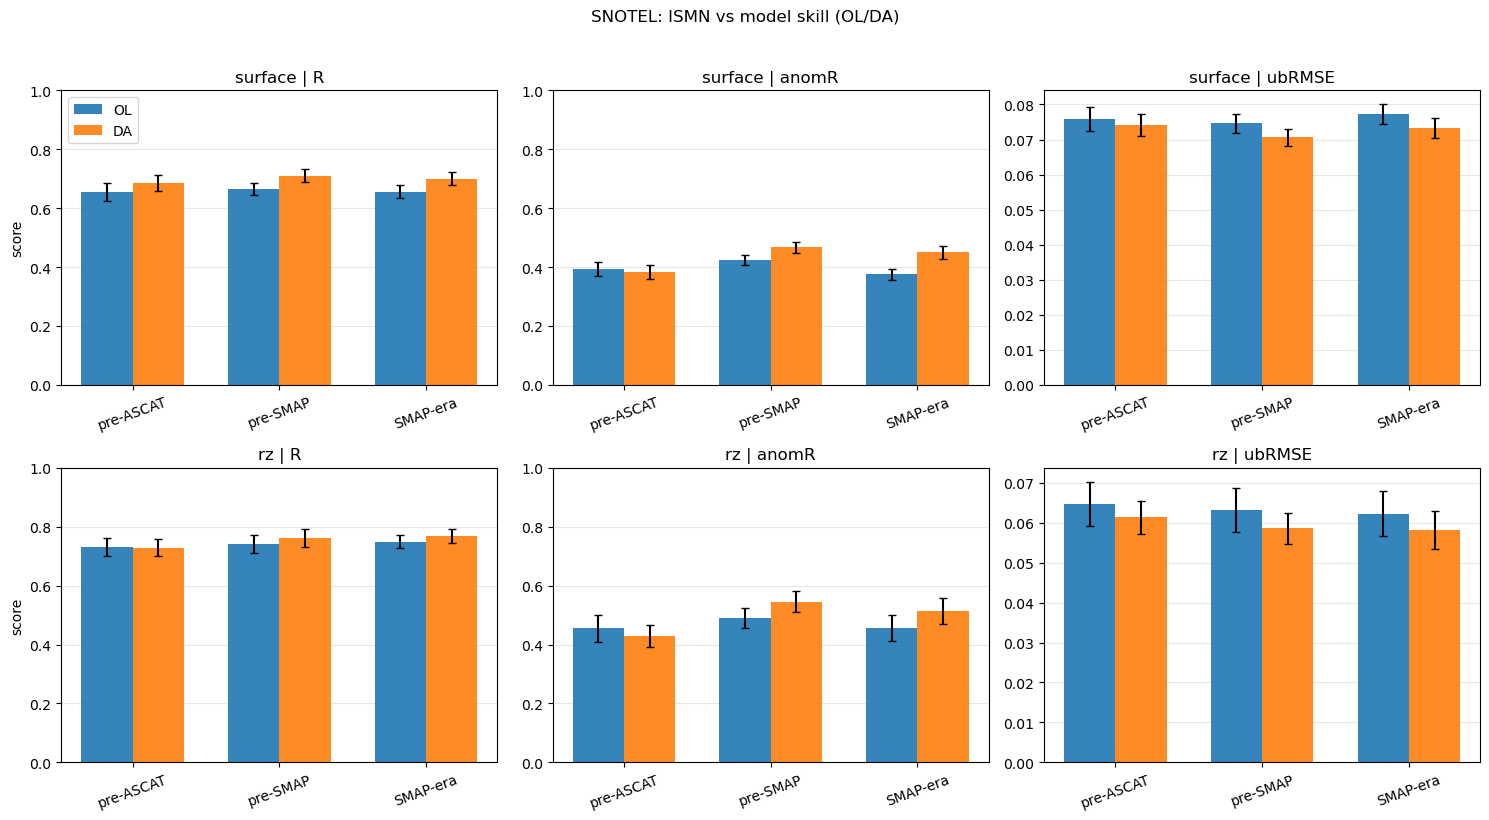

In [10]:
# -------------------------
# Quick diagnostic plot (R, anomR, ubRMSE)
# -------------------------
plot_metrics = ["R", "anomR", "ubRMSE"]
domain_order = ["surface", "rz"]

fig, axs = plt.subplots(2, len(plot_metrics), figsize=(15, 8), sharex=False)
if len(plot_metrics) == 1:
    axs = np.array(axs).reshape(2, 1)

x = np.arange(len(window_names))
bar_w = 0.35

for i, domain in enumerate(domain_order):
    for j, metric in enumerate(plot_metrics):
        ax = axs[i, j]

        for k, exp_key in enumerate(EXPERIMENTS.keys()):
            sub = summary_df[
                (summary_df["domain"] == domain)
                & (summary_df["metric"] == metric)
                & (summary_df["exp"] == exp_key)
            ].set_index("window").reindex(window_names)

            means = sub["mean"].to_numpy(dtype=float)
            sems = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (k - 0.5) * bar_w,
                means,
                width=bar_w,
                yerr=sems,
                capsize=3,
                label=exp_key,
                alpha=0.9,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(window_names, rotation=20)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{domain} | {metric}")
        if j == 0:
            ax.set_ylabel("score")

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.0, 1.0)

axs[0, 0].legend(loc="upper left")
fig.suptitle(f"{NETWORK}: ISMN vs model skill (OL/DA)", y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# -------------------------
# Optional export
# -------------------------
if EXPORT_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    p_network = OUTPUT_DIR / f"{NETWORK}_network_sites_from_metadata.csv"
    p_obs = OUTPUT_DIR / f"{NETWORK}_obs_station_build_status.csv"
    p_stats_raw = OUTPUT_DIR / f"{NETWORK}_site_stats_raw.csv"
    p_stats_qc = OUTPUT_DIR / f"{NETWORK}_site_stats_obs_threshold.csv"
    p_summary = OUTPUT_DIR / f"{NETWORK}_summary_common_sites.csv"

    network_sites_df.to_csv(p_network, index=False)
    obs_site_df.to_csv(p_obs, index=False)
    site_stats_df.to_csv(p_stats_raw, index=False)
    site_stats_qc_df.to_csv(p_stats_qc, index=False)
    summary_df.to_csv(p_summary, index=False)

    for exp_key, df in model_site_maps.items():
        p_map = OUTPUT_DIR / f"{NETWORK}_model_site_map_{exp_key}.csv"
        df.to_csv(p_map, index=False)
        print(f"Wrote {p_map}")

    print("Wrote:")
    print(f"  {p_network}")
    print(f"  {p_obs}")
    print(f"  {p_stats_raw}")
    print(f"  {p_stats_qc}")
    print(f"  {p_summary}")

    if RAW_TIMESERIES_NETCDF.exists():
        print(f"  {RAW_TIMESERIES_NETCDF} (raw timeseries cache)")
else:
    print("EXPORT_CSV=False, no CSV files written")
    if RAW_TIMESERIES_NETCDF.exists():
        print(f"Raw timeseries cache exists at: {RAW_TIMESERIES_NETCDF}")


Wrote outputs_ismn_network_skill/SNOTEL_model_site_map_OL.csv
Wrote outputs_ismn_network_skill/SNOTEL_model_site_map_DA.csv
Wrote:
  outputs_ismn_network_skill/SNOTEL_network_sites_from_metadata.csv
  outputs_ismn_network_skill/SNOTEL_obs_station_build_status.csv
  outputs_ismn_network_skill/SNOTEL_site_stats_raw.csv
  outputs_ismn_network_skill/SNOTEL_site_stats_obs_threshold.csv
  outputs_ismn_network_skill/SNOTEL_summary_common_sites.csv
  outputs_ismn_network_skill/SNOTEL_custom_20000601_20240601_matlab_strict_snotel_n3_c123smv_raw_timeseries.nc (raw timeseries cache)


## Notes

- **Window switch:** set `WINDOW_MODE` to `"two_period"`, `"full_period"`, or `"custom"`.
- **Distance switch:** default is `DISTANCE_METHOD="squared_degree"` with `MAX_DISTANCE_DEG2=0.1`, matching existing `sm_skill_vs_insitu.py` logic.
- **Raw-timeseries cache:** set `WRITE_RAW_TIMESERIES_NETCDF=True` to write `RAW_TIMESERIES_NETCDF` after extraction.
- **Reuse cache:** set `USE_RAW_TIMESERIES_CACHE=True` to load raw obs/model timeseries from NetCDF instead of extracting model files again.
- `NMIN` and `MIN_OBS_DAYS_PER_WINDOW` are strict defaults; lower them for quick dry-runs.


Wrote figure: outputs_ismn_network_skill/SNOTEL_OL_DA_surface_rz_R_anomR_ubRMSE_bar.png


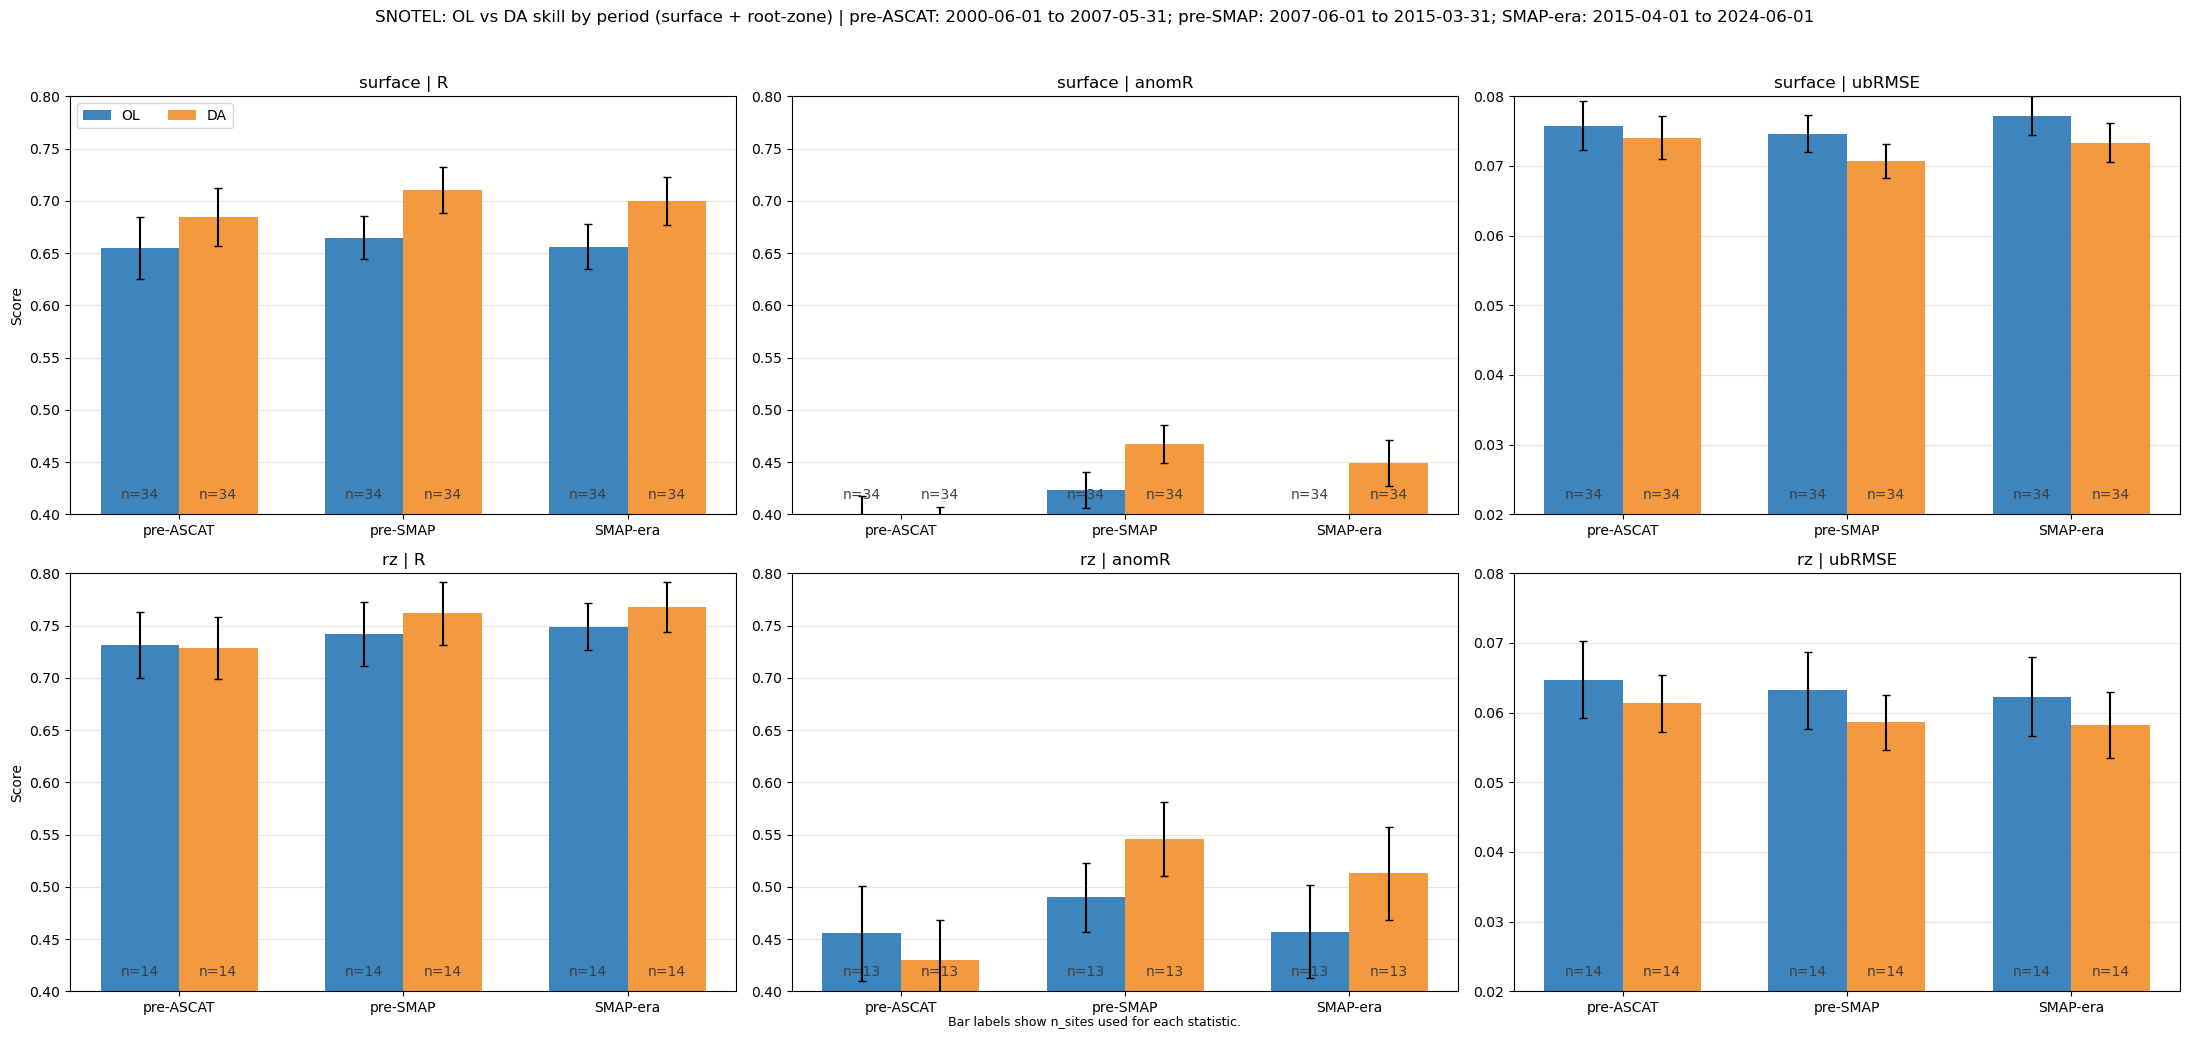

In [12]:
# -------------------------
# Publication-style bar charts (OL vs DA; two windows)
# Metrics: R, anomR, ubRMSE, bias
# Rows: surface (top), root-zone (bottom)
# -------------------------
if "summary_df" not in globals() or len(summary_df) == 0:
    raise RuntimeError("summary_df is missing/empty. Run the summary cell first.")

metric_order = ["R", "anomR", "ubRMSE"]
domain_order = ["surface", "rz"]
exp_order = list(EXPERIMENTS.keys())

# This figure is intended for two time periods (e.g., pre-SMAP and SMAP-era).
if len(window_names) != 2:
    print(
        f"WARNING: expected 2 windows for this figure style, found {len(window_names)}. "
        "Proceeding with all available windows."
    )

colors = {
    "OL": "#2878B5",
    "DA": "#F28E2B",
}

fig, axs = plt.subplots(2, len(metric_order), figsize=(22, 10), sharex=False)
if len(metric_order) == 1:
    axs = np.array(axs).reshape(2, 1)

x = np.arange(len(window_names))
bar_w = 0.35

fig_name = f"{NETWORK}_OL_DA_surface_rz_R_anomR_ubRMSE_bar.png"
fig_path = OUTPUT_DIR / fig_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for i, domain in enumerate(domain_order):
    for j, metric in enumerate(metric_order):
        ax = axs[i, j]

        n_by_exp = {}
        for k, exp_key in enumerate(exp_order):
            sub = summary_df[
                (summary_df["domain"] == domain)
                & (summary_df["metric"] == metric)
                & (summary_df["exp"] == exp_key)
            ].set_index("window").reindex(window_names)

            means = sub["mean"].to_numpy(dtype=float)
            sems = sub["sem"].to_numpy(dtype=float)
            nvals = sub["n_sites"].to_numpy(dtype=float)
            n_by_exp[exp_key] = nvals

            xpos = x + (k - 0.5) * bar_w
            ax.bar(
                xpos,
                means,
                width=bar_w,
                yerr=sems,
                capsize=3,
                label=exp_key,
                color=colors.get(exp_key, None),
                alpha=0.9,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(window_names)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{domain} | {metric}")
        if j == 0:
            ax.set_ylabel("Score")

        # Use fixed y-limits for publication-style comparison.
        if metric in ["R", "anomR"]:
            ax.set_ylim(0.4, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.02, 0.08)

        # Add n-site labels near each bar.
        ymin, ymax = ax.get_ylim()
        span = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0

        for k, exp_key in enumerate(exp_order):
            xpos = x + (k - 0.5) * bar_w
            nvals = n_by_exp.get(exp_key, np.full_like(x, np.nan, dtype=float))

            sub = summary_df[
                (summary_df["domain"] == domain)
                & (summary_df["metric"] == metric)
                & (summary_df["exp"] == exp_key)
            ].set_index("window").reindex(window_names)
            means = sub["mean"].to_numpy(dtype=float)

            for xx, mm, nn in zip(xpos, means, nvals):
                if not np.isfinite(nn):
                    continue

                # Put n labels near the x-axis baseline for readability.
                y_text = ymin + 0.03 * span

                ax.text(
                    xx,
                    y_text,
                    f"n={int(nn)}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    rotation=0,
                    color="0.25",
                )

# Legend once
axs[0, 0].legend(loc="upper left", ncol=len(exp_order))

window_txt = "; ".join([
    f"{name}: {pd.Timestamp(t0).date()} to {pd.Timestamp(t1).date()}"
    for name, t0, t1 in window_bounds
])
fig.suptitle(
    f"{NETWORK}: OL vs DA skill by period (surface + root-zone) | {window_txt}",
    y=1.02,
)
fig.text(0.5, 0.005, "Bar labels show n_sites used for each statistic.", ha="center", fontsize=9)

plt.tight_layout()
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Wrote figure: {fig_path}")
plt.show()
